# Week 4: Supervised Learning — Regression Model

**Intern:** Fiza Zahid Ali  
**Discipline:** Bachelor of Science in Artificial Intelligence (BSAI)  
**Organization:** Zynxis  
**Task:** Supervised Learning — Regression
## 1. Project Objective

The objective of this task is to build supervised machine learning regression models to predict a continuous numerical value.

The California Housing dataset is used for this project, where the target variable represents the median house value.

Three regression algorithms are trained and compared:

1. Linear Regression
2. Ridge Regression
3. Random Forest Regressor

The models are evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

The actual and predicted values are also visualized to evaluate model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Dataset Overview

The California Housing dataset contains information about housing districts in California.

The features include:

- MedInc: Median income
- HouseAge: Median house age
- AveRooms: Average number of rooms
- AveBedrms: Average number of bedrooms
- Population: Population of the district
- AveOccup: Average house occupancy
- Latitude: Latitude of the location
- Longitude: Longitude of the location

The target variable is MedHouseVal, which represents the median house value.

In [7]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [6]:

df.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

## 3. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The models learn patterns from the training data and are evaluated on unseen testing data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


## 4. Linear Regression

Linear Regression is a supervised learning algorithm that models the relationship between input features and a continuous target variable.

It is used as a baseline regression model.

In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred_lr = linear_model.predict(X_test)

In [14]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
print("Linear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("R² Score:", lr_r2)

Linear Regression
MAE: 0.5332001304956553
MSE: 0.5558915986952444
R² Score: 0.5757877060324508


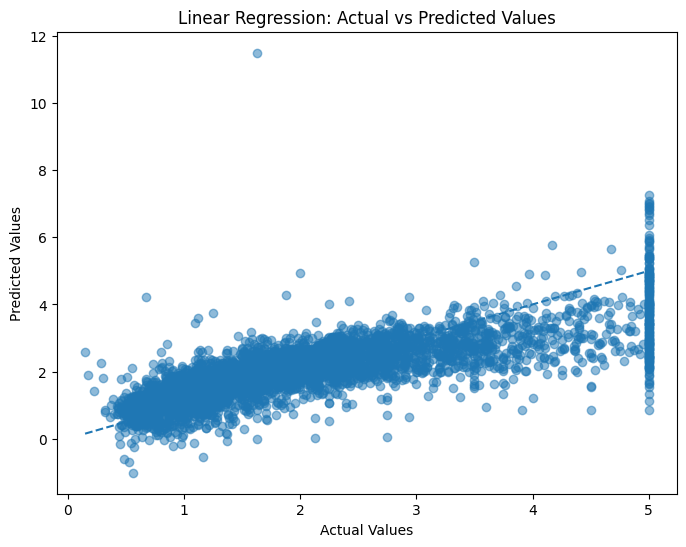

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Linear Regression: Actual vs Predicted Values")

plt.savefig(
    "linear_regression_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Ridge Regression

Ridge Regression is a regularized version of Linear Regression.

It adds a penalty to large model coefficients, which can help reduce overfitting and improve model stability.

In [15]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [16]:
y_pred_ridge = ridge_model.predict(X_test)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)

ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("R² Score:", ridge_r2)

Ridge Regression
MAE: 0.5332039182571153
MSE: 0.5558034669932211
R² Score: 0.5758549611440126


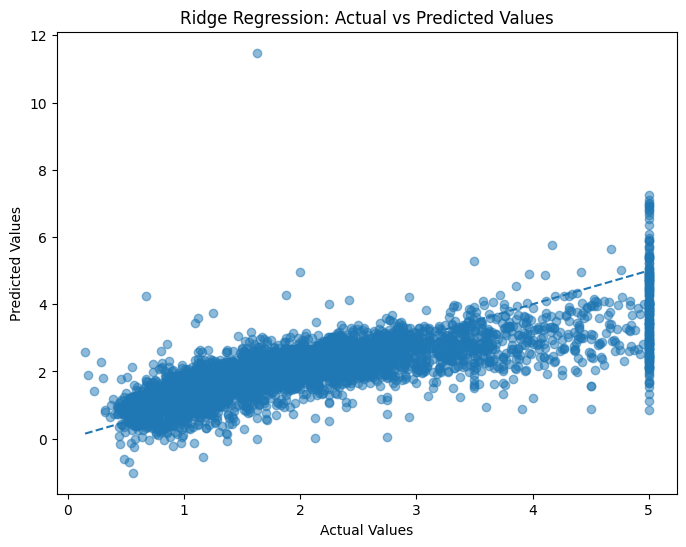

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Ridge Regression: Actual vs Predicted Values")

plt.savefig(
    "ridge_regression_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to predict a continuous numerical value.

It can capture complex nonlinear relationships between features and the target variable.

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [18]:
y_pred_rf = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R² Score:", rf_r2)

Random Forest Regressor
MAE: 0.32754256845930246
MSE: 0.2553684927247781
R² Score: 0.8051230593157366


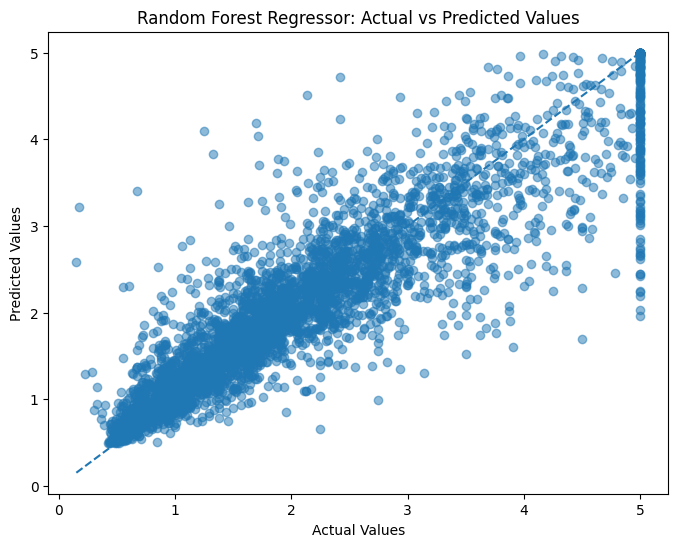

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Random Forest Regressor: Actual vs Predicted Values")

plt.savefig(
    "random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
evaluation_metrics = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        lr_mae,
        ridge_mae,
        rf_mae
    ],
    "MSE": [
        lr_mse,
        ridge_mse,
        rf_mse
    ],
    "R² Score": [
        lr_r2,
        ridge_r2,
        rf_r2
    ]
})

evaluation_metrics.round(4)

,Model,MAE,MSE,R² Score
0,Linear Regression,0.5332,0.5559,0.5758
1,Ridge Regression,0.5332,0.5558,0.5759
2,Random Forest Regressor,0.3275,0.2554,0.8051


## 8. Results Interpretation

The three regression models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

Linear Regression achieved an MAE of 0.5332, an MSE of 0.5559, and an R² Score of 0.5758. Ridge Regression produced very similar results, with an MAE of 0.5332, an MSE of 0.5558, and an R² Score of 0.5759.

Random Forest Regressor achieved the lowest MAE (0.3275) and MSE (0.2554), while also obtaining the highest R² Score (0.8051). This indicates that Random Forest produced smaller prediction errors and explained a larger proportion of the variation in the target variable on the test dataset.

Overall, the evaluation metrics show that Random Forest Regressor performed better than Linear Regression and Ridge Regression on this dataset.